In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from scipy.stats import binomtest, ttest_ind, chi2_contingency
from sklearn.linear_model import SGDClassifier
from sklearn.kernel_approximation import RBFSampler
from sklearn.metrics import precision_recall_curve

train_set = pd.read_csv("train_data.csv")
train_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


In [30]:
len(train_set)

143579

Dans le cadre de ce projet de classification, aucun découpage supplémentaire du jeu de données n’est requis : les partitions d’entraînement et de test ont déjà été constituées et sont respectivement stockées dans les fichiers « train\_data.csv » et « test\_data.csv ».

In [31]:
train_set["Exited"].value_counts()

Exited
0    113129
1     30450
Name: count, dtype: int64

Les deux modalités de la variable cible étant fortement déséquilibrées, nous privilégierons donc la métrique F1-score, plus robuste que l’exactitude dans ce contexte.

# I) Description des variables

| Variable            | Type                  | Description                                                                        | Pertinence pour le modèle            |
| ------------------- | --------------------- | ---------------------------------------------------------------------------------- | ------------------------------------ |
| **CustomerID**      | Identifiant (nominal) | Clé primaire client                                                                | À exclure (aucune valeur prédictive) |
| **Surname**         | Nominal               | Patronyme du client                                                                | À exclure                            |
| **CreditScore**     | Numérique (continu)   | Score de solvabilité : plus il est élevé, plus la probabilité de défaut est faible | ✔︎                                   |
| **Geography**       | Nominal               | Pays de résidence : *France*, *Spain*, *Germany*                                   | ✔︎                                   |
| **Gender**          | Nominal               | Sexe : *Male*, *Female*                                                            | ✔︎                                   |
| **Age**             | Numérique (continu)   | Âge du client                                                                      | ✔︎                                   |
| **Tenure**          | Numérique (discret)   | Ancienneté (années dans la banque)                                                 | ✔︎                                   |
| **Balance**         | Numérique (continu)   | Solde du compte courant                                                            | ✔︎                                   |
| **NumOfProducts**   | Numérique (discret)   | Nombre de produits détenus                                                         | ✔︎                                   |
| **HasCrCard**       | Binaire               | Possession d’une carte de crédit (1 = oui)                                         | ✔︎                                   |
| **IsActiveMember**  | Binaire               | Statut de membre actif (1 = oui)                                                   | ✔︎                                   |
| **EstimatedSalary** | Numérique (continu)   | Salaire estimé                                                                     | ✔︎                                   |
| **Exited**          | Binaire (cible)       | Fermeture du compte (1 = oui)                                                      | —                                    |

L’unité d’analyse est le client ; chaque ligne correspond donc à un individu unique.

# II) Plan d’analyse statistique

Notre démarche analytique s’articule en trois temps :

-caractérisation univariée de chaque prédicteur ;

-examen bivarié de leur relation avec la variable cible ;

-exploration des surfaces de décision afin d’évaluer la séparabilité intrinsèque des classes dans l’espace des caractéristiques.

## II.1) Exploration univariée de l’ensemble des variables

### II.1.1) Crédit Score

Le CreditScore constitue un proxy de la solvabilité : plus la valeur est basse, plus le risque de défaut augmente. Les seuils d’interprétation ne sont toutefois pas universels ; ils varient selon le cadre réglementaire propre à chaque pays et les standards internes adoptés par la banque.

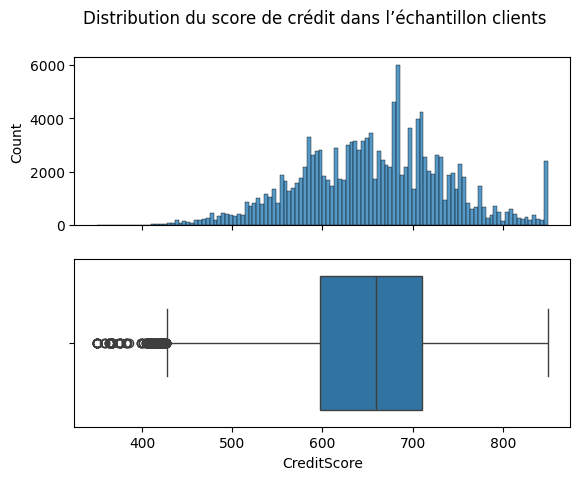

count    143579.000000
mean        656.411704
std          80.210361
min         350.000000
25%         597.000000
50%         659.000000
75%         710.000000
max         850.000000
Name: CreditScore, dtype: float64

In [32]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Distribution du score de crédit dans l’échantillon clients")
sns.histplot(data=train_set, x="CreditScore", ax=ax[0])
sns.boxplot(data=train_set, x="CreditScore", ax=ax[1])
plt.show()
train_set["CreditScore"].describe()

Chez les clients résidant en France, Allemagne et Espagne, le CreditScore s’établit en moyenne autour de 656. La distribution apparaît quasi gaussienne, confirmant une symétrie et une faible asymétrie. Quelques valeurs aberrantes sont néanmoins visibles dans la queue gauche du box-plot : elles correspondent aux profils les plus risqués. Le cœur de la distribution (≈ 580 – 750) suggère qu’une large majorité des clients présentent un score de crédit plutôt intermédiaire.


### II.1.2) Géographie des clients

Nous commencerons par établir la distribution des effectifs par pays de résidence.

In [33]:
train_set["Geography"].value_counts()

Geography
France     81886
Spain      31588
Germany    30105
Name: count, dtype: int64

La France concentre la plus grande part de la clientèle, tandis que l’Espagne et l’Allemagne affichent des effectifs comparables, l’Espagne devançant toutefois légèrement l’Allemagne.

### II.1.3) Analyse de la variable Gender

In [34]:
train_set["Gender"].value_counts()

Gender
Male      80966
Female    62613
Name: count, dtype: int64

On observe une légère sur-représentation de la clientèle masculine au sein du portefeuille.

### II.1.4) Variable Age

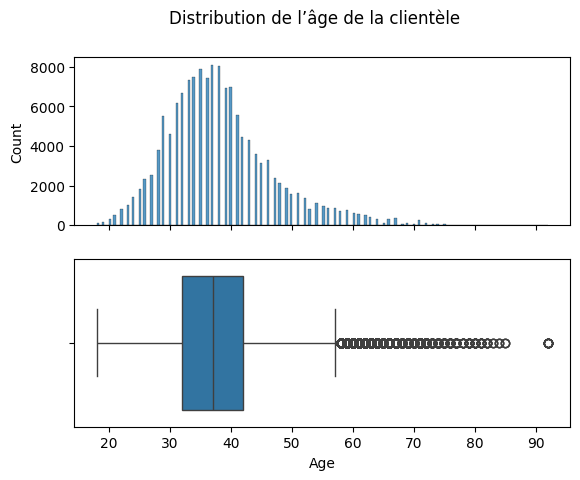

count    143579.000000
mean         38.144476
std           8.871711
min          18.000000
25%          32.000000
50%          37.000000
75%          42.000000
max          92.000000
Name: Age, dtype: float64

In [35]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Distribution de l’âge de la clientèle")
sns.histplot(data=train_set, x="Age", ax=ax[0])
sns.boxplot(data=train_set, x="Age", ax=ax[1])
plt.show()
train_set["Age"].describe()

Chez les clients résidant en France, Allemagne et Espagne, l’âge moyen s’établit à ≈ 38 ans. La distribution se rapproche d’une loi normale, bien qu’un léger allongement de la queue droite signale quelques valeurs extrêmes. Le gros du contingent se situe entre 30 et 40 ans, confirmant la prépondérance d’une clientèle d’âge intermédiaire.

### II.1.5) Tenure (ancienneté)

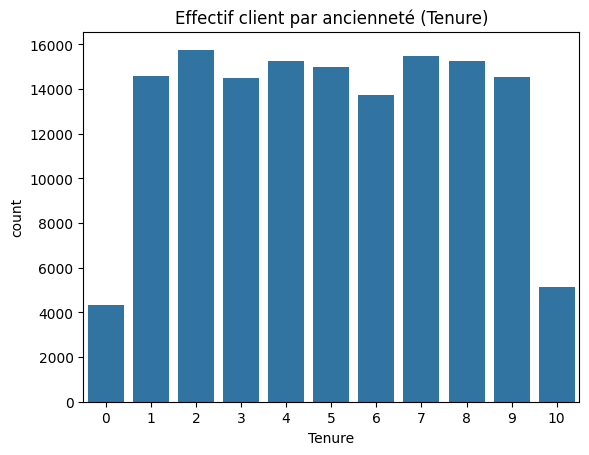

In [36]:
sns.countplot(data=train_set, x="Tenure")
plt.title("Effectif client par ancienneté (Tenure)")
plt.show()

La distribution d’ancienneté (Tenure) suggère le scénario suivant :

Les clients ayant 10 ans d’ancienneté représentent une minorité : l’établissement comptait encore peu d’usagers à ses débuts.

Un pic d’acquisition est ensuite visible pour les clients entrés il y a 9 ans, signe d’une forte phase de croissance cette année-là.

Entre 8 et 2 ans d’ancienneté, les effectifs demeurent globalement stables, traduisant un rythme d’acquisition régulier.

Le léger creux observé chez les tout nouveaux clients (0–1 an) peut provenir d’un ralentissement récent du recrutement ou, plus simplement, du fait que l’exercice en cours n’est pas terminé.

En somme, l’évolution temporelle de la clientèle reflète une phase d’expansion initiale, puis une cadence d’acquisition quasi constante, avant une baisse relative sur la dernière période.

### II.1.6) Balance

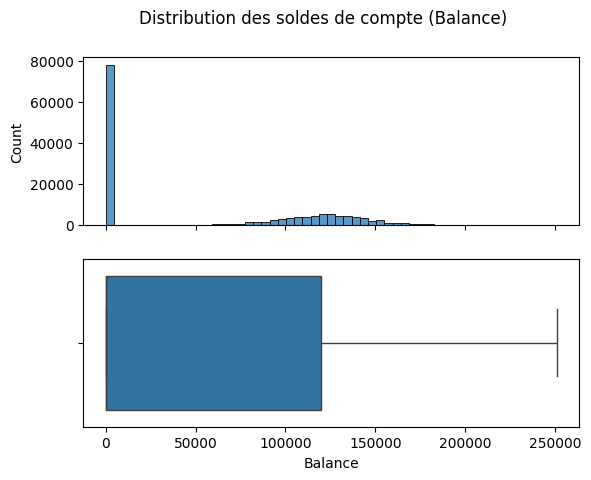

count    143579.000000
mean      55533.640642
std       62822.616346
min           0.000000
25%           0.000000
50%           0.000000
75%      119948.090000
max      250898.090000
Name: Balance, dtype: float64

In [37]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Distribution des soldes de compte (Balance)")
sns.histplot(data=train_set, x="Balance", ax=ax[0])
sns.boxplot(data=train_set, x="Balance", ax=ax[1])
plt.show()
train_set["Balance"].describe()

La variable Balance présente une distribution zero-inflated : une proportion substantielle de clients affiche un solde nul, tandis que les soldes strictement positifs se rapprochent d’une loi normale, sans outliers apparents sur le box-plot. La moyenne, toutes géographies confondues, s’établit autour de 55 728 €. 

### II.1.7) NumOfProducts

In [38]:
train_set["NumOfProducts"].value_counts()

NumOfProducts
2    73301
1    67364
3     2510
4      404
Name: count, dtype: int64

La grande majorité des clients possède un ou deux produits bancaires, tandis que les portefeuilles comprenant trois ou quatre produits restent très marginalisés.

### II.1.8) HasCrCard

In [39]:
train_set["HasCrCard"].value_counts()

HasCrCard
1.0    108274
0.0     35305
Name: count, dtype: int64

La variable HasCrCard révèle un fort taux de détention : la grande majorité des clients possède effectivement une carte de crédit, témoignant d’une pénétration élevée de ce produit dans le portefeuille.

### II.1.9) IsActiveMember

In [40]:
train_set["IsActiveMember"].value_counts()

IsActiveMember
0.0    72249
1.0    71330
Name: count, dtype: int64

La proportion de membres actifs se révèle quasiment égale à celle des membres inactifs ; nous pouvons vérifier statistiquement cette parité à l’aide d’un test binomial.

In [41]:
print("H0: La proportion de clients inactifs est exactement de 50 %.")

alpha = 0.02

p_value = binomtest(
    k=train_set["IsActiveMember"].value_counts()[1], n=len(train_set), p=0.50
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: La proportion de clients inactifs est exactement de 50 %.
Nous avons assez d'évidence pour rejeter H0


Le test exact de proportion n’ayant pas permis de rejeter l’hypothèse nulle au seuil α = 2 %, nous concluons qu’au niveau de confiance correspondant (98 %), la proportion de clients actifs est statistiquement équivalente à celle des clients inactifs.

### II.1.10) Salaire

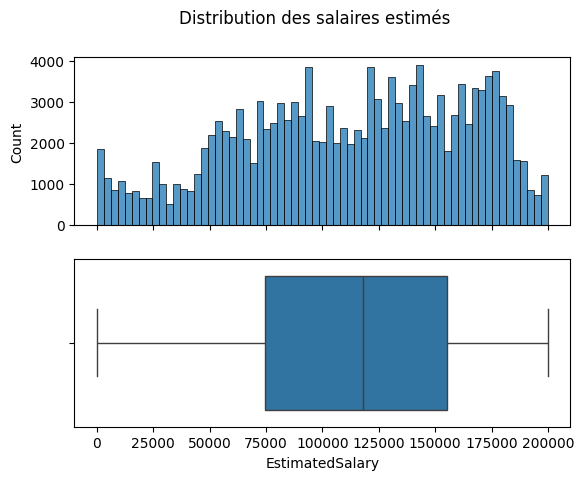

count    143579.000000
mean     112530.072465
std       50301.718378
min          11.580000
25%       74580.800000
50%      117931.100000
75%      155149.685000
max      199992.480000
Name: EstimatedSalary, dtype: float64

In [42]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Distribution des salaires estimés")
sns.histplot(data=train_set, x="EstimatedSalary", ax=ax[0])
sns.boxplot(data=train_set, x="EstimatedSalary", ax=ax[1])
plt.show()
train_set["EstimatedSalary"].describe()

La variable **EstimatedSalary** présente une moyenne d’environ 112 423 €, une distribution fortement asymétrique et un minimum aberrant de 11,58 €. La majorité des observations se situe entre 40 000 € et 180 000 €, cohérentes avec des rémunérations annuelles. Compte tenu du nombre élevé de valeurs aberrantes, nous n’intégrerons pas cette variable au modèle.

## II.2) Analyse multivarié.

Avant de passer aux corrélations croisées, nous regroupons les prédicteurs en trois familles :

| Catégorie                 | Variables                                                |
| ------------------------- | -------------------------------------------------------- |
| **Démographiques**        | *Geography* (pays de résidence), *Gender*, *Age*         |
| **Monétaires**            | *CreditScore*, *Balance*, *EstimatedSalary*              |
| **Fidélité & Engagement** | *Tenure*, *NumOfProducts*, *HasCrCard*, *IsActiveMember* |


### II.2.1) Focus sur les variables démographiques

Cette catégorie regroupe trois attributs : la géographie (pays de résidence), le genre et l’âge.

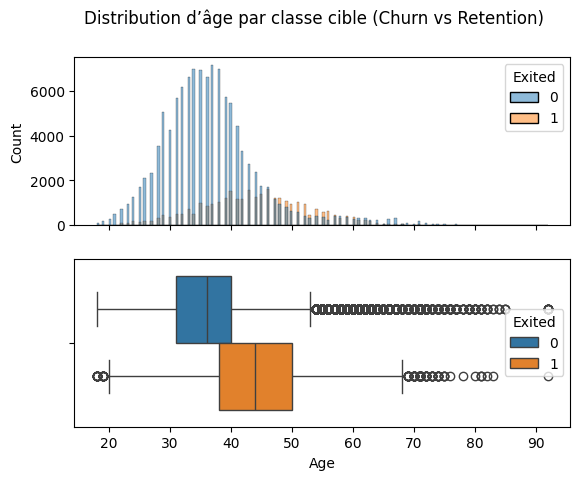

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,36.583765,8.166737,18.0,31.0,36.0,40.0,92.0
1,30450.0,43.942890,8.981339,18.0,38.0,44.0,50.0,92.0


In [43]:
fig, ax = plt.subplots(2, 1, sharex=True)
plt.suptitle("Distribution d’âge par classe cible (Churn vs Retention)")
sns.histplot(data=train_set, x="Age", hue="Exited", ax=ax[0])
sns.boxplot(data=train_set, x="Age", hue="Exited", ax=ax[1])
plt.show()
train_set.groupby("Exited")["Age"].describe()

In [44]:
pd.crosstab(train_set["Geography"], train_set["Exited"], normalize="index")

Exited,0,1
Geography,,
France,0.834550,0.165450
Germany,0.619731,0.380269
Spain,0.827339,0.172661


In [45]:
pd.crosstab(train_set["Gender"], train_set["Exited"], normalize="index")

Exited,0,1
Gender,,
Female,0.719307,0.280693
Male,0.840983,0.159017


Les distributions d’âge mettent en évidence une sur-concentration des clients sortants dans la tranche 48-55 ans, décalant nettement l’histogramme des résiliés vers la droite. Les boxplots confirment cette dissymétrie :

bornes, quartiles et médianes distincts ;

étendue plus large pour les sortants ;

deux valeurs aberrantes dans la queue gauche du groupe « Exited ».

En moyenne, les clients ayant quitté la banque ont 44 ans contre 37 ans pour ceux restés. Côté géographie et genre, le taux de churn est le plus élevé chez les résidents allemands et chez les femmes, tandis que France et Espagne présentent des taux similaires.

Implications feature engineering

Créer une variable binaire Age_48_55 (1 si 48 ≤ âge ≤ 55, sinon 0).

Après one-hot encoding de Geography, ne conserver que Geography_Germany pour capter l’effet pays.

Conditions requises pour un test t (bilatéral, groupes indépendants)
Indépendance : l’âge de chaque client est indépendant de celui des autres.

Origine commune : tous les individus proviennent du même établissement bancaire.

Normalité : l’âge suit une distribution approximativement normale dans chaque groupe, avec > 30 observations par classe.

Même variance : variances comparables permettant l’usage du test de Student classique.

In [46]:
print("H0: L’âge moyen des sortants est égal à celui des clients conservés.")

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0")["Age"], train_set.query("`Exited` == 1")["Age"]
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: L’âge moyen des sortants est égal à celui des clients conservés.
Nous avons assez d'évidence pour rejeter H0


In [47]:
print("H0: Le pays de résidence n’a aucune relation avec la résiliation.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["Geography"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Le pays de résidence n’a aucune relation avec la résiliation.
Nous avons assez d'évidence pour rejeter H0


In [48]:
print("H0: Le genre n’a aucune relation avec la résiliation.")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Gender"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Le genre n’a aucune relation avec la résiliation.
Nous avons assez d'évidence pour rejeter H0


Au seuil α = 2 %, l’hypothèse nulle a été rejetée pour chacune des trois variables démographiques :

Âge : les clients ayant résilié sont significativement plus âgés que ceux restés fidèles ;

Géographie : la probabilité de churn est nettement supérieure pour les résidents allemands ;

Genre : le taux de résiliation est plus élevé chez les femmes.

Étant donné que l’Espagne et la France affichent des taux de churn statistiquement similaires, le one-hot encoding de Geography se limitera à l’indicateur Geography_Germany. Les variables Gender et Age seront également conservées pour la modélisation.

### II.2.2) Focus sur les variables monétaires

Les variables monétaires incluent le score de crédit, la balance et le salaire, toutes trois continues. Nous procéderons donc d’abord à une analyse bivariée avec la cible, puis à une analyse trivariée à l’aide de surfaces scatter.

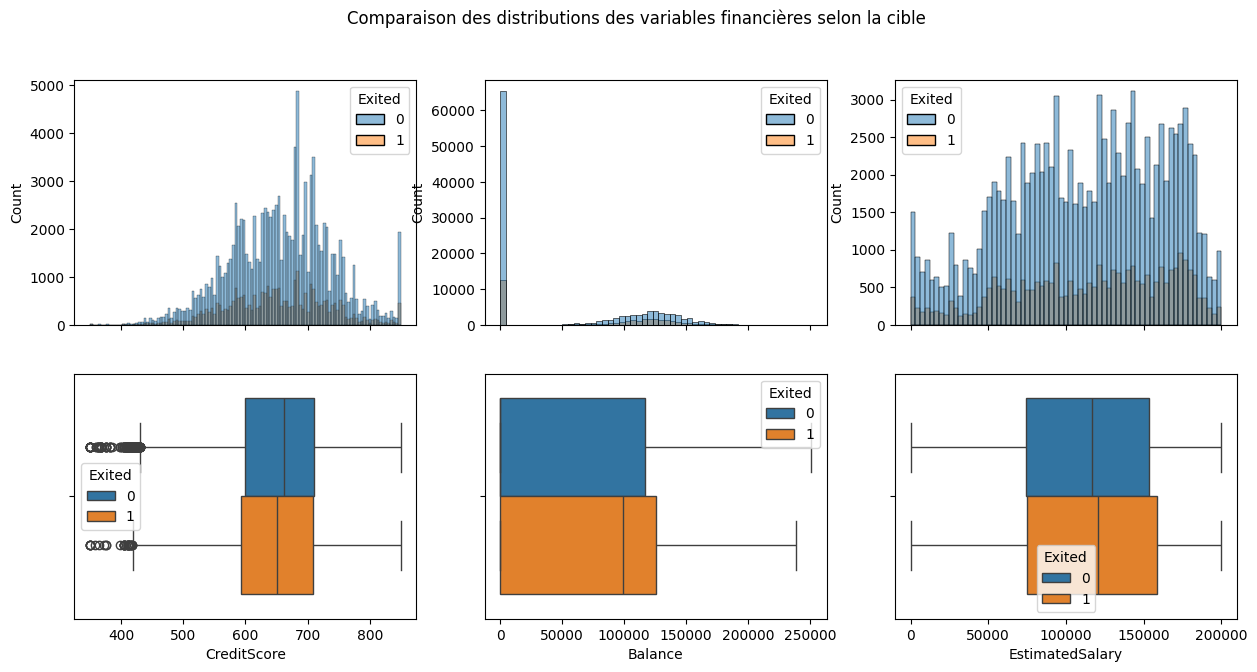

In [49]:
fig, ax = plt.subplots(2, 3, sharex="col")
fig.set_size_inches(15, 7)
plt.suptitle("Comparaison des distributions des variables financières selon la cible")
sns.histplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[0, 0])
sns.boxplot(data=train_set, x="CreditScore", hue="Exited", ax=ax[1, 0])
sns.histplot(data=train_set, x="Balance", hue="Exited", ax=ax[0, 1])
sns.boxplot(data=train_set, x="Balance", hue="Exited", ax=ax[1, 1])
sns.histplot(data=train_set, x="EstimatedSalary", hue="Exited", ax=ax[0, 2])
sns.boxplot(data=train_set, x="EstimatedSalary", hue="Exited", ax=ax[1, 2])
plt.show()

In [50]:
train_set.groupby("Exited")["CreditScore"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,657.532136,79.899437,350.0,599.0,662.0,711.0,850.0
1,30450.0,652.249031,81.221163,350.0,593.0,651.0,709.0,850.0


In [51]:
train_set.groupby("Exited")["Balance"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,51274.230558,62196.885812,0.0,0.0,0.00,116811.12,250898.09
1,30450.0,71358.363247,62606.860862,0.0,0.0,98959.19,125521.18,238387.56


In [52]:
train_set.query("`Balance` != 0").groupby("Exited")["Balance"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,47803.0,121343.899521,25541.298733,3768.69,104154.250,122359.50,138023.520,250898.09
1,17858.0,121674.440635,23686.386782,3768.69,106920.255,121874.89,135927.445,238387.56


In [53]:
train_set.groupby("Exited")["EstimatedSalary"].describe()

,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,113129.0,112024.082699,50228.170190,11.58,74287.53,116971.05,153727.32,199992.48
1,30450.0,114409.944918,50530.496339,11.58,74898.80,120893.77,158830.36,199992.48


Les trois histogrammes n’indiquent aucune séparation nette entre les deux modalités de la cible ; de même, les boxplots des trois variables se superposent presque parfaitement. En moyenne, les clients ayant résilié sont moins fiables que ceux restés. La différence de moyenne observée sur la balance provient surtout du déséquilibre entre soldes nuls et soldes positifs ; si l’on ne considère que les soldes ≠ 0, les moyennes convergent aussitôt. Pour le salaire estimé, l’écart moyen est minime.

Nous passerons donc aux tests d’hypothèse : la balance n’étant normalement distribuée qu’après exclusion des soldes nuls, le test *t* ne portera que sur ces observations. Le salaire, qui n’est pas normal, sera examiné ultérieurement, après éventuelle transformation lors du feature engineering.

**Conditions du test *t* (Student)**

* Indépendance des observations pour le score de crédit et la balance.
* Tous les clients appartiennent au même établissement.
* Normalité du score de crédit et des soldes non nuls, avec plus de 30 observations par groupe.
* Variances comparables entre groupes pour ces variables.


In [54]:
print("H0: Les scores de crédit moyens sont identiques entre sortants et non-sortants.")

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0")["CreditScore"],
    train_set.query("`Exited` == 1")["CreditScore"],
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Les scores de crédit moyens sont identiques entre sortants et non-sortants.
Nous avons assez d'évidence pour rejeter H0


In [55]:
print(
    "H0: Pour les soldes strictement positifs, la balance moyenne sont identiques entre sortants et non-sortants."
)

alpha = 0.02

p_value = ttest_ind(
    train_set.query("`Exited` == 0 and `Balance` != 0")["Balance"],
    train_set.query("`Exited` == 1 and `Balance` != 0")["Balance"],
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Pour les soldes strictement positifs, la balance moyenne sont identiques entre sortants et non-sortants.
Nous n'avons pas assez d'évidence pour rejeter H0.


Nous avons rejeté $H_0$ pour le **CreditScore**, mais pas pour la **Balance ≠ 0**. Au seuil α = 2 %, cela signifie que :

* les clients ayant résilié présentent **en moyenne** un score de crédit plus faible (fiabilité moindre) que ceux restés ;
* parmi les soldes non nuls, la moyenne de balance **ne diffère pas significativement** entre les deux groupes.

Visuellement, la distribution des balances n’offre aucune séparation franche ; la box-plot des sortants est simplement décalée vers la gauche—décalage plus marqué sous la médiane, puis s’estompant au troisième quartile. Malgré cette faible discriminativité, la balance segmente tout de même la population en deux sous-ensembles affichant des taux de churn distincts ; nous conserverons donc la variable **Balance** dans le modèle.

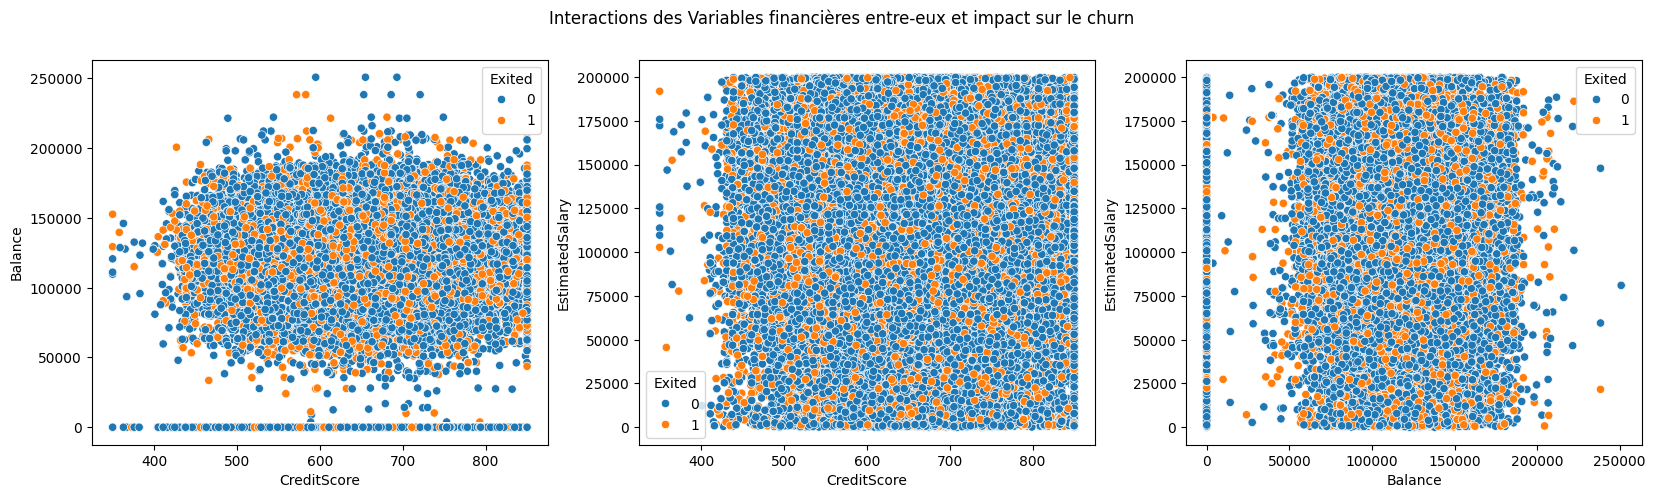

In [56]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(20, 5)
plt.suptitle("Interactions des Variables financières entre-eux et impact sur le churn")
sns.scatterplot(data=train_set, x="CreditScore", y="Balance", hue="Exited", ax=ax[0])
sns.scatterplot(
    data=train_set, x="CreditScore", y="EstimatedSalary", hue="Exited", ax=ax[1]
)
sns.scatterplot(
    data=train_set, x="Balance", y="EstimatedSalary", hue="Exited", ax=ax[2]
)
plt.show()

Aucune frontière de décision nette n’émerge.

### II.2.3) Analyse des indicateurs de fidélité

Cette catégorie rassemble quatre variables : l’ancienneté (*Tenure*), le nombre de produits détenus, la détention d’une carte de crédit et le statut d’activité.


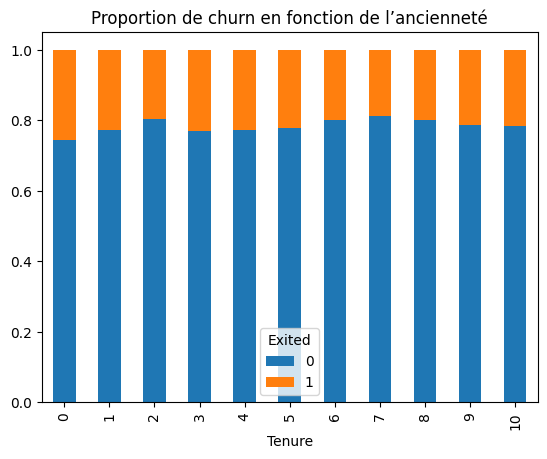

Exited,0,1
Tenure,,
0,0.744133,0.255867
1,0.772512,0.227488
2,0.805023,0.194977
3,0.771265,0.228735
4,0.772563,0.227437
5,0.779832,0.220168
6,0.802712,0.197288
7,0.811684,0.188316
8,0.800223,0.199777


In [57]:
pd.crosstab(train_set["Tenure"], train_set["Exited"], normalize="index").plot(
    kind="bar", stacked=True
)
plt.title("Proportion de churn en fonction de l’ancienneté")
plt.show()

pd.crosstab(train_set["Tenure"], train_set["Exited"], normalize="index")

In [58]:
pd.crosstab(train_set["NumOfProducts"], train_set["Exited"], normalize="index")

Exited,0,1
NumOfProducts,,
1,0.651758,0.348242
2,0.939673,0.060327
3,0.116335,0.883665
4,0.131188,0.868812


In [59]:
pd.crosstab(train_set["HasCrCard"], train_set["Exited"], normalize="index")

Exited,0,1
HasCrCard,,
0.0,0.771732,0.228268
1.0,0.793201,0.206799


In [60]:
pd.crosstab(train_set["IsActiveMember"], train_set["Exited"], normalize="index")

Exited,0,1
IsActiveMember,,
0.0,0.702321,0.297679
1.0,0.874625,0.125375


Le churn atteint son pic chez les clients détenant **plus de deux produits** et **non actifs**, tandis que l’**ancienneté** et la **possession d’une carte de crédit** n’exhibent pas d’effet marqué. Nous allons maintenant soumettre ces relations à des tests statistiques.


In [61]:
print("H0: L’ancienneté n’a aucune relation avec la résiliation..")

alpha = 0.02

p_value = chi2_contingency(pd.crosstab(train_set["Tenure"], train_set["Exited"])).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: L’ancienneté n’a aucune relation avec la résiliation..
Nous avons assez d'évidence pour rejeter H0


In [62]:
print("H0: Le nombre de produits détenus n’a aucune relation avec la résiliation.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["NumOfProducts"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Le nombre de produits détenus n’a aucune relation avec la résiliation.
Nous avons assez d'évidence pour rejeter H0


In [63]:
print(
    "H0: Posséder ou non une carte de crédit n’influence pas la probabilité de résiliation."
)

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["HasCrCard"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Posséder ou non une carte de crédit n’influence pas la probabilité de résiliation.
Nous avons assez d'évidence pour rejeter H0


In [64]:
print("H0: Le statut d’activité n’a aucune relation avec la résiliation.")

alpha = 0.02

p_value = chi2_contingency(
    pd.crosstab(train_set["IsActiveMember"], train_set["Exited"])
).pvalue

if p_value < alpha:
    print("Nous avons assez d'évidence pour rejeter H0")
else:
    print("Nous n'avons pas assez d'évidence pour rejeter H0.")

H0: Le statut d’activité n’a aucune relation avec la résiliation.
Nous avons assez d'évidence pour rejeter H0


L’hypothèse nulle a été rejetée pour l’ensemble des variables de fidélité. Néanmoins, la **Tenure** et la **possession de carte de crédit** présentent un taux de churn pratiquement constant ; nous les écartons donc de la modélisation. Nous conserverons uniquement **IsActiveMember** et **NumOfProducts**. Par ailleurs, les taux de résiliation des clients détenant **3** ou **4** produits étant équivalents, ces deux modalités seront fusionnées afin d’obtenir une variable discrète à trois niveaux.

In [65]:
def simplified_number_product(df):
    df["Simplified_NumOfProducts"] = df["NumOfProducts"].replace({4: 3})
    return df


train_set = simplified_number_product(train_set)
train_set

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Simplified_NumOfProducts
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0,1
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0,2
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0,2
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1,3
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,97639,15759915,Onwumelu,559,Germany,Male,45.0,3,111634.29,1,1.0,1.0,103349.74,0,1
143575,95939,15769974,Shih,597,Germany,Male,41.0,10,119182.73,1,0.0,0.0,121299.14,0,1
143576,152315,15592028,Hsiao,576,Spain,Male,31.0,6,127299.56,1,1.0,1.0,57569.89,0,1
143577,117952,15804009,Ch'ang,751,France,Female,27.0,4,90721.11,1,0.0,0.0,84496.78,0,1


In [66]:
pd.crosstab(
    train_set["Simplified_NumOfProducts"], train_set["Exited"], normalize="index"
)

Exited,0,1
Simplified_NumOfProducts,,
1,0.651758,0.348242
2,0.939673,0.060327
3,0.118394,0.881606


On distingue trois segments présentant des taux de résiliation nettement distincts.

### II.2.4) Interaction entre l’âge et les variables financières

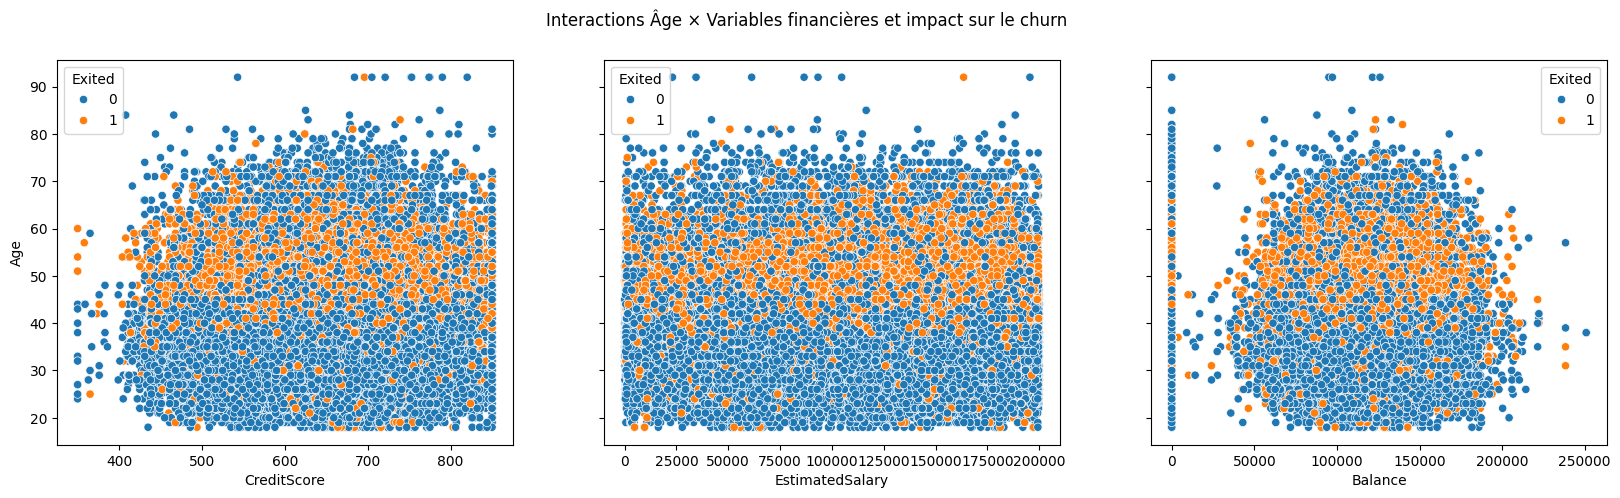

In [67]:
fig, ax = plt.subplots(1, 3, sharey=True)
fig.set_size_inches(20, 5)
plt.suptitle("Interactions Âge × Variables financières et impact sur le churn")
sns.scatterplot(data=train_set, x="CreditScore", y="Age", hue="Exited", ax=ax[0])
sns.scatterplot(data=train_set, x="EstimatedSalary", y="Age", hue="Exited", ax=ax[1])
sns.scatterplot(data=train_set, x="Balance", y="Age", hue="Exited", ax=ax[2])
plt.show()

Aucune frontière de décision nette n’est visible ; toutefois, les clients résiliés se concentrent majoritairement dans la tranche **40 – 70 ans**. Nous pouvons donc créer une variable indicatrice égale à 1 si l’âge du client appartient à cet intervalle, et à 0 sinon.

In [68]:
def binary_age(df):
    df["Age_binary"] = np.select(
        condlist=[(df["Age"] >= 40) & (df["Age"] <= 70)], choicelist=[1], default=0
    )
    return df


train_set = binary_age(train_set)
train_set

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Simplified_NumOfProducts,Age_binary
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0,1,0
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0,2,0
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0,2,0
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1,3,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,97639,15759915,Onwumelu,559,Germany,Male,45.0,3,111634.29,1,1.0,1.0,103349.74,0,1,1
143575,95939,15769974,Shih,597,Germany,Male,41.0,10,119182.73,1,0.0,0.0,121299.14,0,1,1
143576,152315,15592028,Hsiao,576,Spain,Male,31.0,6,127299.56,1,1.0,1.0,57569.89,0,1,0
143577,117952,15804009,Ch'ang,751,France,Female,27.0,4,90721.11,1,0.0,0.0,84496.78,0,1,0


# III) Préprocéssing

## III.1) Nettoyage des données

Nous débutons par l’étape de nettoyage du jeu de données.

In [69]:
train_set.isna().value_counts()

ID     CustomerId  Surname  CreditScore  Geography  Gender  Age    Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited  Simplified_NumOfProducts  Age_binary
False  False       False    False        False      False   False  False   False    False          False      False           False            False   False                     False         143579
Name: count, dtype: int64

Aucune valeur manquante n’a été détectée dans le jeu d’entraînement, et l’analyse exploratoire n’a révélé aucun outlier réellement significatif.

In [70]:
from sklearn import set_config
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

X_train_set = train_set.drop("Exited", axis=1)
y_train_set = train_set["Exited"]
set_config(transform_output="pandas")

## III.2) Encoding

Les variables **Gender** et **Geography**, toutes deux nominales, seront transformées via un **OneHotEncoder** afin de générer un indicateur binaire pour chaque modalité.

In [71]:
encoder = ColumnTransformer(
    [
        (
            "Encoding_onehot",
            OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore"),
            ["Geography", "Gender"],
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
encoder

,transformers,"[('Encoding_onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,'first'
,sparse_output,False


In [72]:
column_encoders = encoder.fit_transform(X_train_set)
column_encoders

,Geography_Germany,Geography_Spain,Gender_Male,ID,CustomerId,Surname,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Simplified_NumOfProducts,Age_binary
0,0.0,0.0,1.0,37765,15794860,Ch'eng,627,28.0,7,131694.04,1,1.0,1.0,161205.61,1,0
1,0.0,0.0,1.0,130453,15728005,Hargreaves,597,34.0,2,0.00,2,0.0,1.0,181419.29,2,0
2,0.0,0.0,1.0,77297,15686810,Ts'ui,724,39.0,7,0.00,2,1.0,1.0,100862.54,2,0
3,1.0,0.0,0.0,40858,15760244,Trevisano,663,56.0,5,118577.24,3,1.0,0.0,61164.45,3,1
4,0.0,0.0,0.0,19804,15810563,French,627,33.0,5,0.00,2,1.0,1.0,103737.82,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,1.0,0.0,1.0,97639,15759915,Onwumelu,559,45.0,3,111634.29,1,1.0,1.0,103349.74,1,1
143575,1.0,0.0,1.0,95939,15769974,Shih,597,41.0,10,119182.73,1,0.0,0.0,121299.14,1,1
143576,0.0,1.0,1.0,152315,15592028,Hsiao,576,31.0,6,127299.56,1,1.0,1.0,57569.89,1,0
143577,0.0,0.0,0.0,117952,15804009,Ch'ang,751,27.0,4,90721.11,1,0.0,0.0,84496.78,1,0


## III.3) Normalisation

L’âge est la seule variable pertinente à distribution gaussienne ; nous lui appliquerons donc une standardisation (z-score). Les autres variables, non normales et dépourvues de valeurs extrêmes, seront redimensionnées par Min-Max scaling. Enfin, le paramètre `remainder="drop"` servira à éliminer les colonnes non pertinentes.

In [73]:
normalizer = ColumnTransformer(
    [
        (
            "MinMax",
            MinMaxScaler(),
            [
                "Age",
                "Geography_Germany",
                "Gender_Male",
                "NumOfProducts",
                "IsActiveMember",
                "Balance",
                "Age_binary",
            ],
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
normalizer

,transformers,"[('MinMax', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [74]:
final_column = normalizer.fit_transform(column_encoders)
final_column

,Age,Geography_Germany,Gender_Male,NumOfProducts,IsActiveMember,Balance,Age_binary
0,0.135135,0.0,1.0,0.000000,1.0,0.524891,0.0
1,0.216216,0.0,1.0,0.333333,1.0,0.000000,0.0
2,0.283784,0.0,1.0,0.333333,1.0,0.000000,0.0
3,0.513514,1.0,0.0,0.666667,0.0,0.472611,1.0
4,0.202703,0.0,0.0,0.333333,1.0,0.000000,0.0
...,...,...,...,...,...,...,...
143574,0.364865,1.0,1.0,0.000000,1.0,0.444939,1.0
143575,0.310811,1.0,1.0,0.000000,0.0,0.475024,1.0
143576,0.175676,0.0,1.0,0.000000,1.0,0.507376,0.0
143577,0.121622,0.0,0.0,0.000000,0.0,0.361585,0.0


In [75]:
pipeline = make_pipeline(encoder, normalizer)
pipeline

,steps,"[('columntransformer-1', ...), ('columntransformer-2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Encoding_onehot', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [76]:
train_set_finale = pipeline.fit_transform(X_train_set, y_train_set)
train_set_finale

,Age,Geography_Germany,Gender_Male,NumOfProducts,IsActiveMember,Balance,Age_binary
0,0.135135,0.0,1.0,0.000000,1.0,0.524891,0.0
1,0.216216,0.0,1.0,0.333333,1.0,0.000000,0.0
2,0.283784,0.0,1.0,0.333333,1.0,0.000000,0.0
3,0.513514,1.0,0.0,0.666667,0.0,0.472611,1.0
4,0.202703,0.0,0.0,0.333333,1.0,0.000000,0.0
...,...,...,...,...,...,...,...
143574,0.364865,1.0,1.0,0.000000,1.0,0.444939,1.0
143575,0.310811,1.0,1.0,0.000000,0.0,0.475024,1.0
143576,0.175676,0.0,1.0,0.000000,1.0,0.507376,0.0
143577,0.121622,0.0,0.0,0.000000,0.0,0.361585,0.0


# IV) Modélisation et évaluation

Conformément aux recommandations de la cheatsheet scikit-learn, nous commencerons par entraîner un **SGDClassifier**, puis nous explorerons les méthodes d’approximation de noyau.

In [77]:
model = SGDClassifier(
    random_state=42,
    loss="log_loss",
    class_weight="balanced",
    penalty=None,
)
param_grid = {
    "alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "eta0": [1e-3, 1e-2, 1e-1, 1],
    "shuffle": [False, True],
    "warm_start": [False, True],
    "average": [False, True],
}

grisearch = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring="f1")
grisearch.fit(train_set_finale, y_train_set)
print(grisearch.best_params_)
print(grisearch.best_score_)
print(grisearch.score(train_set_finale, y_train_set))
best_model = grisearch.best_estimator_

{'alpha': 0.0001, 'average': False, 'eta0': 0.001, 'shuffle': False, 'warm_start': False}
0.5684570851282554
0.5689823623180953


La performance reste insuffisante ; nous allons donc recourir à une approximation de noyau en employant l’estimateur **`RBFSampler`**.

In [78]:
pipe = make_pipeline(RBFSampler(random_state=42), best_model)

param_grid = {
    "rbfsampler__gamma": [2.0, 3.0, 4.0],
    "rbfsampler__n_components": [2000, 3000, 4000],
}

grisearch_rbf = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=5, scoring="f1")
grisearch_rbf.fit(train_set_finale, y_train_set)
print(grisearch_rbf.best_params_)
print(grisearch_rbf.best_score_)
print(grisearch_rbf.score(train_set_finale, y_train_set))

best_model = grisearch_rbf.best_estimator_

{'rbfsampler__gamma': 4.0, 'rbfsampler__n_components': 4000}
0.6437518587100263
0.6444749391991956


/tmp/ipykernel_2519/1772248237.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


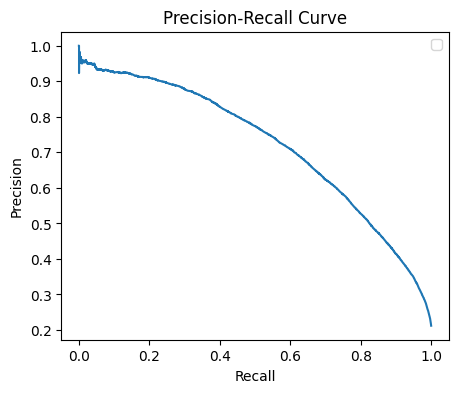

In [79]:
precision, recall, thresholds = precision_recall_curve(
    y_train_set, best_model.predict_proba(train_set_finale)[:, 1]
)

plt.figure(figsize=(5, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve


def best_f1_threshold(y_true, y_proba, eps=1e-12):
    """
    Calcule le seuil qui maximise le score F1 à partir de y_true (0/1) et y_proba (probabilités).
    Retourne: best_threshold, best_f1, best_precision, best_recall
    """
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    # precision et recall ont une longueur = len(thresholds) + 1
    # On calcule F1 seulement pour les points associés à thresholds
    precision_t = precision[:-1]
    recall_t = recall[:-1]

    f1 = (2 * precision_t * recall_t) / (precision_t + recall_t + eps)

    best_idx = int(np.nanargmax(f1))
    best_threshold = float(thresholds[best_idx])
    best_f1 = float(f1[best_idx])
    best_precision = float(precision_t[best_idx])
    best_recall = float(recall_t[best_idx])

    return best_threshold, best_f1, best_precision, best_recall


def apply_threshold(y_proba, threshold):
    """
    Convertit des probabilités en prédictions 0/1 selon un seuil.
    """
    y_proba = np.asarray(y_proba).astype(float)
    return (y_proba >= threshold).astype(int)


# ----------------------------
# Exemple d'utilisation
# ----------------------------

# y_val: vraies classes (0/1) du jeu de validation
# y_proba_val: probabilités (sortie du modèle) sur validation
# y_proba_test: probabilités sur le jeu de test

# best_thr, best_f1, p, r = best_f1_threshold(y_val, y_proba_val)
# print(f"Seuil optimal = {best_thr:.6f}, F1 = {best_f1:.4f}, precision = {p:.4f}, recall = {r:.4f}")

# y_pred_test = apply_threshold(y_proba_test, best_thr)
# print("Aperçu prédictions test:", y_pred_test[:20])

best_threshold, best_f1, best_precision, best_recall = best_f1_threshold(
    y_train_set, best_model.predict_proba(train_set_finale)[:, 1]
)
best_threshold, best_f1

(0.6276052016156656, 0.6607383028207479)

In [82]:
kaggle_test_set = pd.read_csv("test_data.csv")
kaggle_test_set.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,67897,15585246,Bancks,585,France,Female,53.0,2,0.00,2,1.0,1.0,91830.75
1,163075,15604551,Robb,606,France,Male,24.0,2,0.00,1,0.0,1.0,90876.95
2,134760,15729040,Ugochukwu,633,Germany,Male,44.0,1,118907.60,1,1.0,0.0,47777.15
3,68707,15792329,Hs?,602,Germany,Male,40.0,2,149961.99,2,1.0,1.0,82696.84
4,3428,15617166,Genovesi,645,France,Male,31.0,4,132351.29,1,1.0,0.0,151887.16


In [83]:
kaggle_test_set = binary_age(kaggle_test_set)
kaggle_test_set = simplified_number_product(kaggle_test_set)

In [84]:
kaggle_test_set_finale = pipeline.transform(kaggle_test_set)
kaggle_test_set_finale

,Age,Geography_Germany,Gender_Male,NumOfProducts,IsActiveMember,Balance,Age_binary
0,0.472973,0.0,0.0,0.333333,1.0,0.000000,1.0
1,0.081081,0.0,1.0,0.000000,1.0,0.000000,0.0
2,0.351351,1.0,1.0,0.000000,0.0,0.473928,1.0
3,0.297297,1.0,1.0,0.333333,1.0,0.597701,1.0
4,0.175676,0.0,1.0,0.000000,0.0,0.527510,0.0
...,...,...,...,...,...,...,...
21450,0.229730,0.0,1.0,0.333333,1.0,0.000000,0.0
21451,0.391892,0.0,0.0,0.000000,0.0,0.000000,1.0
21452,0.189189,0.0,0.0,0.333333,1.0,0.000000,0.0
21453,0.513514,0.0,0.0,0.000000,0.0,0.000000,1.0


In [ ]:
y_pred = apply_threshold(
    best_model.predict_proba(kaggle_test_set_finale)[:, 1], best_threshold
)

array([0, 0, 1, ..., 0, 1, 0], shape=(21455,))

In [ ]:
results = pd.DataFrame({"ID": kaggle_test_set["ID"], "Exited": ypred})
results.set_index("ID")

,Exited
ID,
67897,0
163075,0
134760,1
68707,0
3428,0
...,...
24790,0
152608,1
28134,0


In [ ]:
results.to_csv("submission_with_optimised_normaliser.csv")

# V) Intervalle de confiance

Nous avons obtenu un F1-score de 64.443 % sur le benchmark Kaggle ; je vais à présent calculer l’intervalle de confiance à 95 % (marge d’erreur ± 5 %).

In [ ]:
p = 0.64443
n = len(kaggle_test_set)
se = np.sqrt((p * (1 - p)) / n)
borne1 = round(p - 1.96 * se, 5)
borne2 = round(p + 1.96 * se, 5)
intervalle_confiance = [borne1, borne2]
intervalle_confiance

[np.float64(0.63802), np.float64(0.65084)]

Le véritable score f1 a 95% de chance d'être situé entre 63.802 % et 65.084 %.